正在导出FC模型到: /user/C/fc_model.onnx
fc_model.onnx 导出完成
正在导出RNN模型到: /user/C/rnn_model.onnx
rnn_model.onnx 导出完成
正在导出CNN模型到: /user/C/cnn_model.onnx
cnn_model.onnx 导出完成


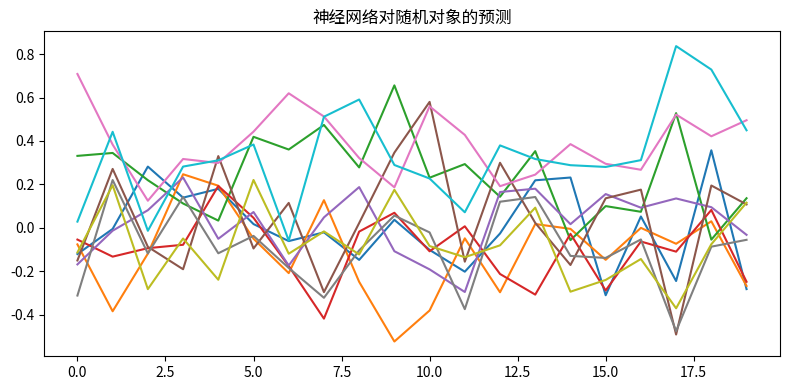

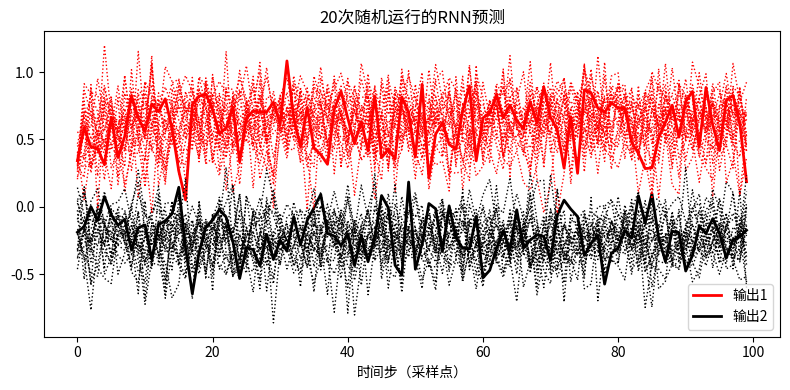

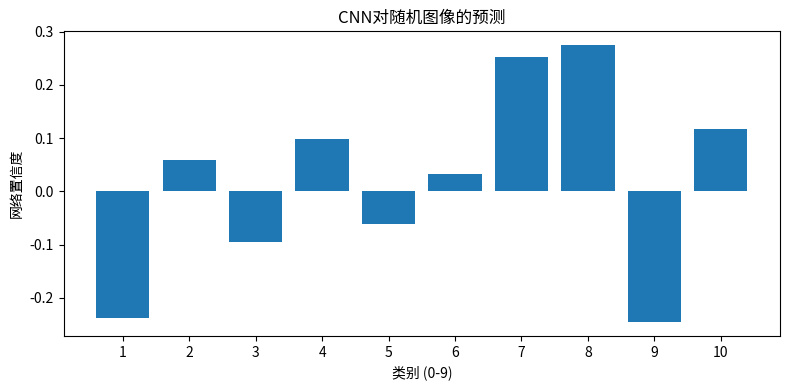


=== 检查/user/C目录文件 ===
rnn_model.onnx , 文件大小: 2160 bytes
cnn_model.onnx , 文件大小: 108939 bytes
fc_model.onnx , 文件大小: 102245 bytes


In [0]:
import os
# 先确保目标文件夹存在
os.makedirs("/user/C", exist_ok=True)
os.environ["PYTORCH_DISABLE_NNPACK"] = "1"

import warnings
warnings.filterwarnings(
    "ignore",
    message="Exporting a model to ONNX with a batch_size other than 1, with a variable length with RNN_TANH"
)

import torch
import torch.nn as nn
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


# ==================================================
# 1. 全连接神经网络 (FC)
# ==================================================
fc_model = nn.Sequential(
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

dummy_input_fc = torch.randn(1, 784, dtype=torch.float32)
fc_save_path = os.path.join("/user/C", "fc_model.onnx")
print(f"正在导出FC模型到: {fc_save_path}")
torch.onnx.export(
    model=fc_model,
    args=dummy_input_fc,
    f=fc_save_path,
    input_names=["data_0"],
    output_names=["dense_1"],
    opset_version=12
)
print("fc_model.onnx 导出完成")

ort_session_fc = ort.InferenceSession(fc_save_path)
result = []
x_data = np.random.randn(784, 20).astype(np.float32)
for i in range(x_data.shape[1]):
    x = x_data[:, i:i+1].T
    outputs = ort_session_fc.run(None, {"data_0": x})
    result.append(outputs[0])

plt.figure(figsize=(8, 4))
plot_data = np.concatenate(result, axis=0)
plt.plot(plot_data)
plt.title("神经网络对随机对象的预测")
plt.tight_layout()


# ==================================================
# 2. 循环神经网络 (RNN)
# ==================================================
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=5, hidden_size=10, num_layers=1, batch_first=False)
        self.fc = nn.Linear(10, 2)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        out = self.fc(rnn_out)
        return out

rnn_model = RNNModel()
dummy_input_rnn = torch.randn(100, 1, 5, dtype=torch.float32)
rnn_save_path = os.path.join("/user/C", "rnn_model.onnx")
print(f"正在导出RNN模型到: {rnn_save_path}")
torch.onnx.export(
    model=rnn_model,
    args=dummy_input_rnn,
    f=rnn_save_path,
    input_names=["data_0"],
    output_names=["dense_0"],
    opset_version=12
)
print("rnn_model.onnx 导出完成")

ort_session_rnn = ort.InferenceSession(rnn_save_path)
plt.figure(figsize=(8, 4))
for x in range(20):
    raw_data = np.random.randn(5, 100).astype(np.float32)
    input_tensor = raw_data.T.reshape(100, 1, 5)
    outputs = ort_session_rnn.run(None, {"data_0": input_tensor})
    onnx_output = outputs[0]
    plot_data = onnx_output.reshape(100, 2)

    if x == 0:
        plt.plot(plot_data[:, 0], color="red", label="输出1", linewidth=2, linestyle="-")
        plt.plot(plot_data[:, 1], color="black", label="输出2", linewidth=2, linestyle="-")
    else:
        plt.plot(plot_data[:, 0], color="red", linewidth=1, linestyle=":")
        plt.plot(plot_data[:, 1], color="black", linewidth=1, linestyle=":")

plt.title("20次随机运行的RNN预测")
plt.xlabel("时间步（采样点）")
plt.legend()
plt.tight_layout()


# ==================================================
# 3. 卷积神经网络 (CNN)
# ==================================================
cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(26 * 26 * 4, 10)
)

dummy_input_cnn = torch.randn(1, 1, 28, 28, dtype=torch.float32)
cnn_save_path = os.path.join("/user/C", "cnn_model.onnx")
print(f"正在导出CNN模型到: {cnn_save_path}")
torch.onnx.export(
    model=cnn_model,
    args=dummy_input_cnn,
    f=cnn_save_path,
    input_names=["data_0"],
    output_names=["dense_0"],
    opset_version=12
)
print("cnn_model.onnx 导出完成")

ort_session_cnn = ort.InferenceSession(cnn_save_path)
raw_image = np.random.randn(28, 28, 1).astype(np.float32)
permuted_image = np.transpose(raw_image, (2, 1, 0))
input_tensor = permuted_image.reshape(1, 1, 28, 28)

outputs = ort_session_cnn.run(None, {"data_0": input_tensor})
onnx_output = outputs[0]
plot_data = onnx_output.flatten()

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), plot_data)
plt.title("CNN对随机图像的预测")
plt.xlabel("类别 (0-9)")
plt.ylabel("网络置信度")
plt.xticks(range(1, 11))
plt.tight_layout()

plt.show()

# 验证文件是否生成
print("\n=== 检查/user/C目录文件 ===")
for fname in os.listdir("/user/C"):
    if fname.endswith(".onnx"):
        fullp = os.path.join("/user/C", fname)
        fsize = os.path.getsize(fullp)
        print(f"{fname} , 文件大小: {fsize} bytes")
